# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# User Input Variables
Change these to test any combination

In [2]:
# ── Change these as needed ──
FEAT1         = "CulmenLength"   # first feature
FEAT2         = "CulmenDepth"    # second feature
CLASS1        = "Adelie"         # mapped to  1
CLASS2        = "Gentoo"         # mapped to -1
LR            = 0.01
EPOCHS        = 100
MSE_THRESHOLD = 0.01
BIAS          = 1                # 1 = use bias, 0 = no bias

# Preprocessing

In [3]:
df = pd.read_csv("penguins.csv")
df

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,Torgersen,3750.0
1,Adelie,39.5,17.4,186.0,Torgersen,3800.0
2,Adelie,40.3,18.0,195.0,Torgersen,3250.0
3,Adelie,NaN,NaN,NaN,Torgersen,NaN
4,Adelie,36.7,19.3,193.0,Torgersen,3450.0
...,...,...,...,...,...,...
145,Gentoo,NaN,NaN,NaN,Biscoe,NaN
146,Gentoo,46.8,14.3,215.0,Biscoe,4850.0
147,Gentoo,50.4,15.7,222.0,Biscoe,5750.0
148,Gentoo,45.2,14.8,212.0,Biscoe,5200.0


In [4]:
df.head()

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,Torgersen,3750.0
1,Adelie,39.5,17.4,186.0,Torgersen,3800.0
2,Adelie,40.3,18.0,195.0,Torgersen,3250.0
3,Adelie,NaN,NaN,NaN,Torgersen,NaN
4,Adelie,36.7,19.3,193.0,Torgersen,3450.0


In [5]:
df.tail()

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
145,Gentoo,NaN,NaN,NaN,Biscoe,NaN
146,Gentoo,46.8,14.3,215.0,Biscoe,4850.0
147,Gentoo,50.4,15.7,222.0,Biscoe,5750.0
148,Gentoo,45.2,14.8,212.0,Biscoe,5200.0
149,Gentoo,49.9,16.1,213.0,Biscoe,5400.0


In [6]:
df.shape

(150, 6)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Species           0
CulmenLength      2
CulmenDepth       2
FlipperLength     2
OriginLocation    0
BodyMass          2
dtype: int64

In [9]:
df.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass
count,148.000000,148.000000,148.000000,148.000000
mean,45.089865,17.377703,199.277027,4186.486486
std,5.385578,2.072129,14.160797,817.476925
min,34.100000,13.100000,172.000000,2700.000000
25%,40.500000,15.700000,187.750000,3550.000000
50%,46.100000,17.800000,196.000000,3950.000000
75%,49.350000,18.900000,212.250000,4681.250000
max,59.600000,21.500000,230.000000,6300.000000


In [10]:
df.columns

Index(['Species', 'CulmenLength', 'CulmenDepth', 'FlipperLength',
       'OriginLocation', 'BodyMass'],
      dtype='object')

In [11]:
num_col = ['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass']

for i in num_col:
    mask = (df["Species"] == "Adelie") & (df["OriginLocation"] == "Torgersen")
    mean_fill = df.loc[mask, i].mean()
    df.loc[mask, i] = df.loc[mask, i].fillna(mean_fill).round(1)

for i in num_col:
    mask = (df["Species"] == "Gentoo") & (df["OriginLocation"] == "Biscoe")
    mean_fill = df.loc[mask, i].mean()
    df.loc[mask, i] = df.loc[mask, i].fillna(mean_fill).round(1)

df.isnull().sum()

Species           0
CulmenLength      0
CulmenDepth       0
FlipperLength     0
OriginLocation    0
BodyMass          0
dtype: int64

In [12]:
origin_location = {"Dream": 1, "Biscoe": 2, "Torgersen": 3}
df["OriginLocation"] = df["OriginLocation"].map(origin_location)
df

,Species,CulmenLength,CulmenDepth,FlipperLength,OriginLocation,BodyMass
0,Adelie,39.1,18.7,181.0,3,3750.0
1,Adelie,39.5,17.4,186.0,3,3800.0
2,Adelie,40.3,18.0,195.0,3,3250.0
3,Adelie,38.8,19.0,189.3,3,3763.2
4,Adelie,36.7,19.3,193.0,3,3450.0
...,...,...,...,...,...,...
145,Gentoo,47.5,14.9,216.4,2,5128.1
146,Gentoo,46.8,14.3,215.0,2,4850.0
147,Gentoo,50.4,15.7,222.0,2,5750.0
148,Gentoo,45.2,14.8,212.0,2,5200.0


In [13]:
df["Species"].value_counts()

Species
Adelie       50
Chinstrap    50
Gentoo       50
Name: count, dtype: int64

# Feature Combinations Plot

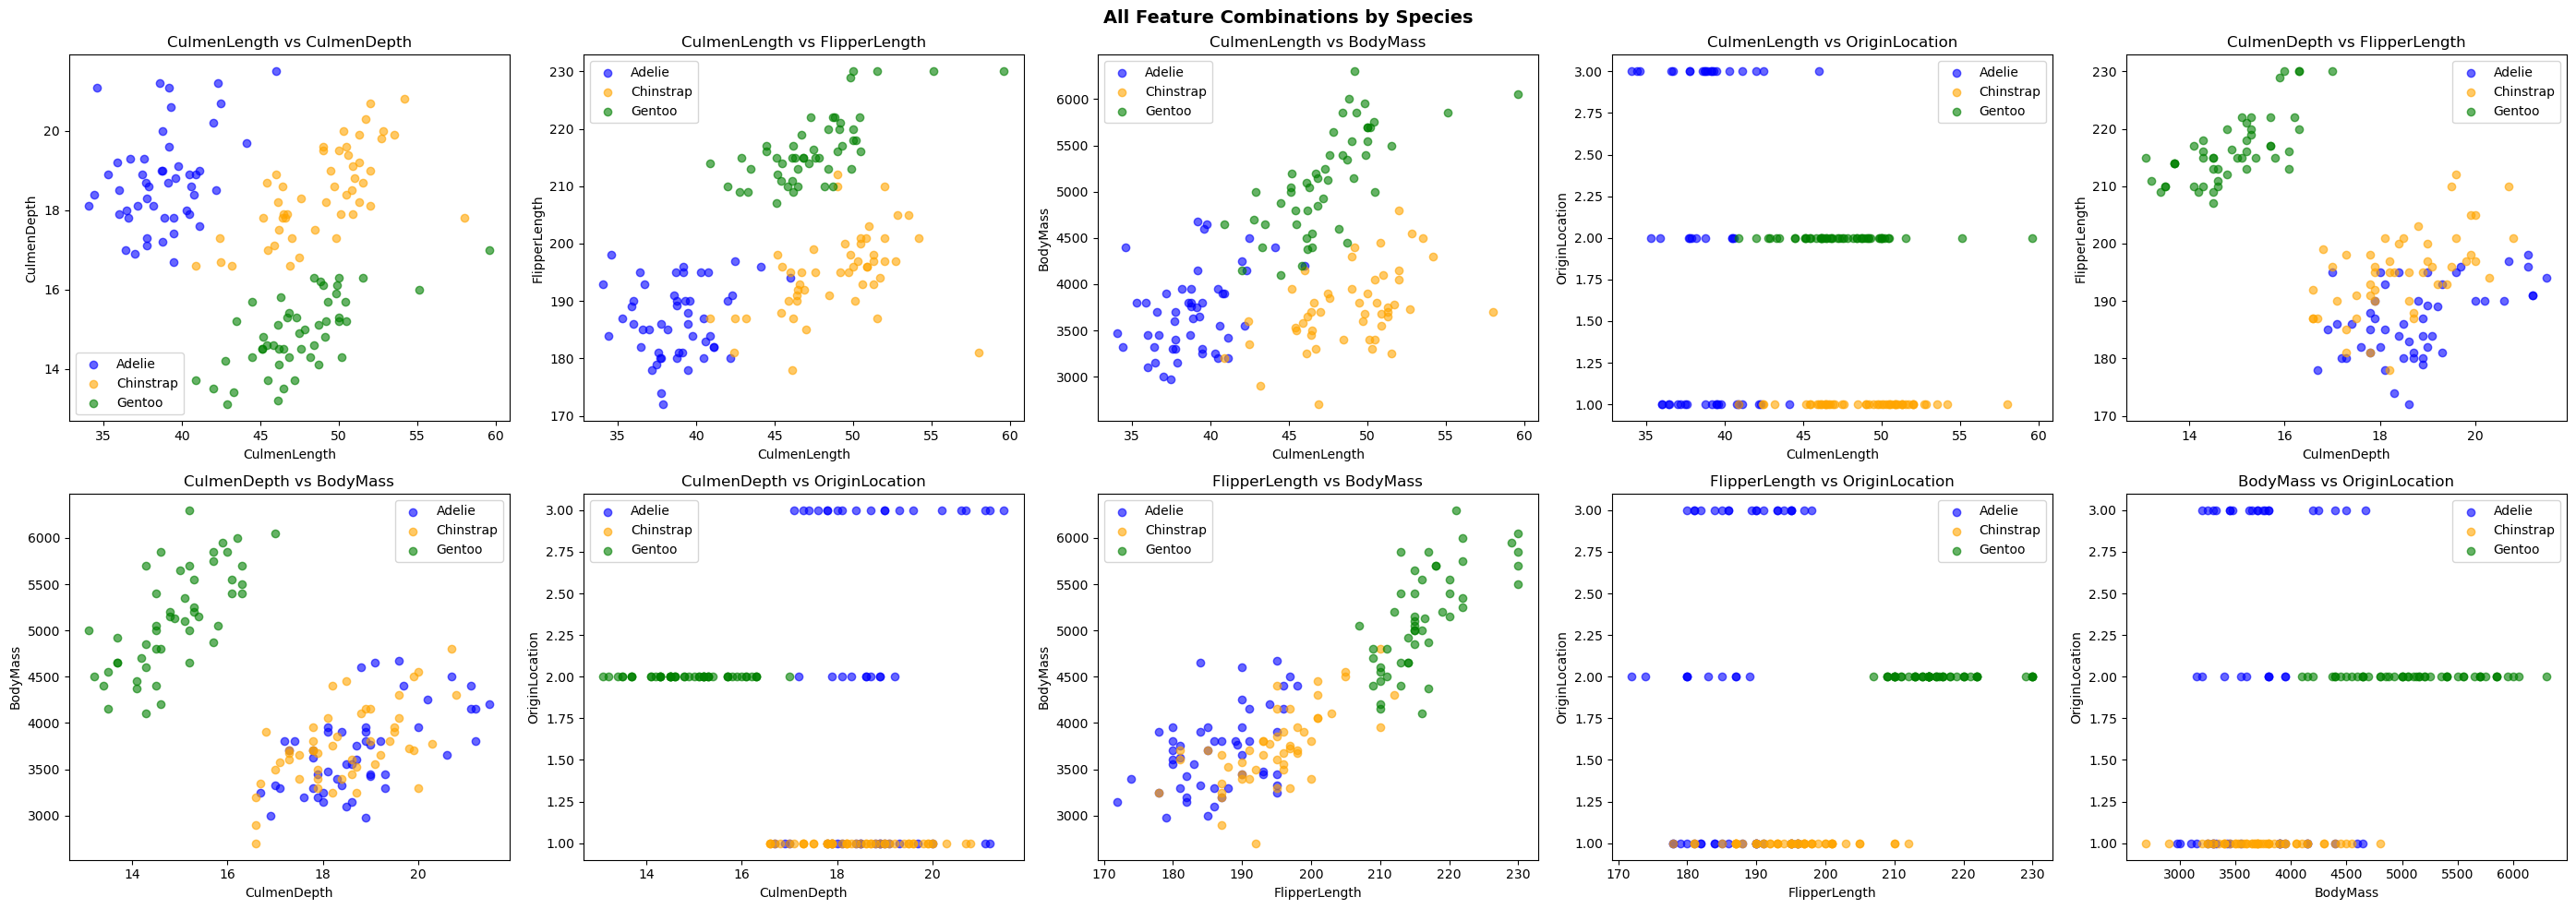

In [ ]:
features = ["CulmenLength", "CulmenDepth", "FlipperLength", "BodyMass", "OriginLocation"]
combos   = list(combinations(features, 2))   # 10 combinations

colors = {"Adelie": "blue", "Chinstrap": "orange", "Gentoo": "green"}

fig, axes = plt.subplots(2, 3, figsize=(28, 10))
axes = axes.flatten()

for i, (f1, f2) in enumerate(combos):
    ax = axes[i]
    for species, color in colors.items():
        subset = df[df["Species"] == species]
        ax.scatter(subset[f1], subset[f2], label=species, color=color, alpha=0.6)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f"{f1} vs {f2}")
    ax.legend()

plt.suptitle("All Feature Combinations by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("penguin_all_combinations.png", dpi=150)
plt.show()

# Split Data

In [15]:
train_df, test_df = train_test_split(
    df, test_size=0.4, stratify=df["Species"], random_state=42
)
print("Train:", train_df["Species"].value_counts().to_dict())
print("Test: ", test_df["Species"].value_counts().to_dict())

Train: {'Gentoo': 30, 'Adelie': 30, 'Chinstrap': 30}
Test:  {'Adelie': 20, 'Chinstrap': 20, 'Gentoo': 20}


# Filter Classes & Features using Variables

In [16]:
# filter classes
train_filtered = train_df[train_df["Species"].isin([CLASS1, CLASS2])].copy()
test_filtered  = test_df[test_df["Species"].isin([CLASS1, CLASS2])].copy()

# map labels using variables
label_map = {CLASS1: 1, CLASS2: -1}
train_filtered["Species"] = train_filtered["Species"].map(label_map)
test_filtered["Species"]  = test_filtered["Species"].map(label_map)

# select only the 2 features chosen by user
x      = train_filtered[[FEAT1, FEAT2]]
y      = train_filtered["Species"]
x_test = test_filtered[[FEAT1, FEAT2]]
y_test = test_filtered["Species"]

print("x_train shape:", x.shape)
print("x_test shape :", x_test.shape)
print("Classes      :", y.value_counts().to_dict())

x_train shape: (60, 2)
x_test shape : (40, 2)
Classes      : {-1: 30, 1: 30}


# Helper Function

In [17]:
def signum(x):
    return 1 if x >= 0 else -1

# Perceptron

In [18]:
def perceptron_train(x, y, w0, w1, w2, bias, lr, epochs):
    for _ in range(epochs):
        for x1, x2, target in zip(x.iloc[:, 0], x.iloc[:, 1], y):
            net    = w1 * x1 + w2 * x2 + w0 * bias
            y_pred = signum(net)
            if y_pred != target:
                error = target - y_pred
                w1 = w1 + lr * error * x1
                w2 = w2 + lr * error * x2
                w0 = w0 + lr * error * bias
    return w1, w2, w0

In [19]:
def perceptron_test(x_test, y_test, w0, w1, w2, bias):
    predictions = []
    TP = TN = FP = FN = 0

    for x1, x2, target in zip(x_test.iloc[:, 0], x_test.iloc[:, 1], y_test):
        net  = w1 * x1 + w2 * x2 + w0 * bias
        pred = signum(net)
        predictions.append(pred)

        if   pred ==  1 and target ==  1: TP += 1
        elif pred == -1 and target == -1: TN += 1
        elif pred ==  1 and target == -1: FP += 1
        elif pred == -1 and target ==  1: FN += 1

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    cm = np.array([[TP, FN],
                   [FP, TN]])
    return predictions, accuracy, cm

In [20]:
# train
w0, w1, w2 = np.random.rand() * 0.01, np.random.rand() * 0.01, np.random.rand() * 0.01
w1, w2, w0 = perceptron_train(x, y, w0, w1, w2, BIAS, LR, EPOCHS)
print("Updated weights: w0=", w0, " w1=", w1, " w2=", w2)

# test
preds, acc, cm = perceptron_test(x_test, y_test, w0, w1, w2, BIAS)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Updated weights: w0= 0.02713318284626942  w1= -0.325019278974103  w2= 0.8245488953787401
Accuracy: 1.0
Confusion Matrix:
 [[20  0]
 [ 0 20]]


# Decision Boundary — Perceptron

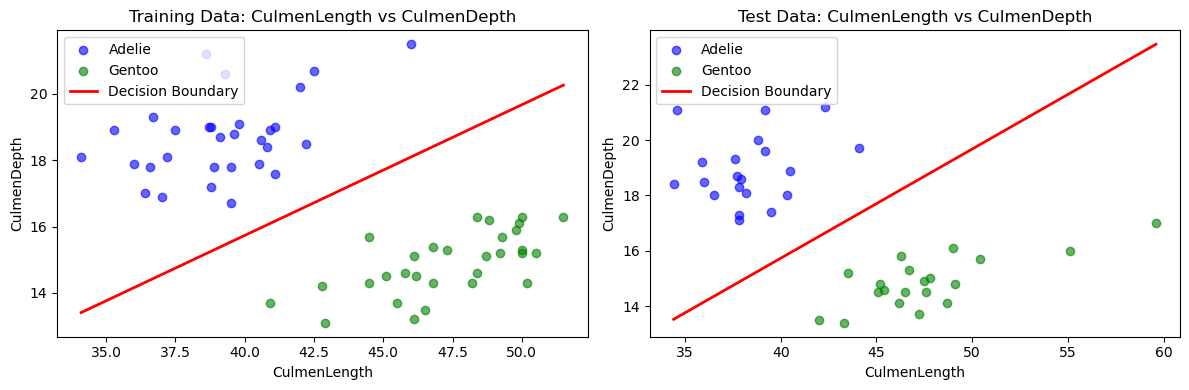

In [21]:
def plot_decision_boundary(x_train, y_train, x_test, y_test, w0, w1, w2, bias, feat1, feat2, class1, class2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = {1: "blue", -1: "green"}
    labels = {1: class1, -1: class2}

    for ax, x_data, y_data, title in [
        (axes[0], x_train, y_train, "Training Data"),
        (axes[1], x_test,  y_test,  "Test Data")
    ]:
        for cls, color in colors.items():
            mask = y_data == cls
            ax.scatter(x_data.loc[mask, feat1], x_data.loc[mask, feat2],
                       color=color, label=labels[cls], alpha=0.6)
        x1_vals = np.linspace(x_data[feat1].min(), x_data[feat1].max(), 100)
        if w2 != 0:
            x2_vals = -(w1 * x1_vals + w0 * bias) / w2
            ax.plot(x1_vals, x2_vals, color="red", linewidth=2, label="Decision Boundary")
        ax.set_xlabel(feat1)
        ax.set_ylabel(feat2)
        ax.set_title(f"{title}: {feat1} vs {feat2}")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_decision_boundary(x, y, x_test, y_test, w0, w1, w2, BIAS, FEAT1, FEAT2, CLASS1, CLASS2)

# Adaline

In [22]:
# scale using variables-based x and x_test
scaler        = StandardScaler()
x_scaled      = pd.DataFrame(scaler.fit_transform(x),      columns=x.columns,      index=x.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test),     columns=x_test.columns, index=x_test.index)

In [23]:
def adaline_train(x, y, w0, w1, w2, bias, lr, epochs, mse_threshold):
    mse = float('inf')
    for _ in range(epochs):
        total_error = 0
        for x1, x2, target in zip(x.iloc[:, 0], x.iloc[:, 1], y):
            net   = w1 * x1 + w2 * x2 + w0 * bias
            error = target - net
            w1 = w1 + lr * error * x1
            w2 = w2 + lr * error * x2
            w0 = w0 + lr * error * bias
            total_error += error ** 2
        mse = total_error / len(y)
        if mse < mse_threshold:
            break
    return w1, w2, w0, mse

In [24]:
def adaline_test(x_test, y_test, w0, w1, w2, bias):
    predictions = []
    TP = TN = FP = FN = 0

    for x1, x2, target in zip(x_test.iloc[:, 0], x_test.iloc[:, 1], y_test):
        net  = w1 * x1 + w2 * x2 + w0 * bias
        pred = signum(net)
        predictions.append(pred)

        if   pred ==  1 and target ==  1: TP += 1
        elif pred == -1 and target == -1: TN += 1
        elif pred ==  1 and target == -1: FP += 1
        elif pred == -1 and target ==  1: FN += 1

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    cm = np.array([[TP, FN],
                   [FP, TN]])
    return predictions, accuracy, cm

In [25]:
# train
w0, w1, w2 = np.random.rand() * 0.01, np.random.rand() * 0.01, np.random.rand() * 0.01
w1, w2, w0, mse = adaline_train(x_scaled, y, w0, w1, w2, BIAS, LR, EPOCHS, MSE_THRESHOLD)
print("MSE score:", mse)

# test
preds, acc, cm = adaline_test(x_test_scaled, y_test, w0, w1, w2, BIAS)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

MSE score: 0.07537405230357562
Accuracy: 1.0
Confusion Matrix:
 [[20  0]
 [ 0 20]]


# Decision Boundary — Adaline

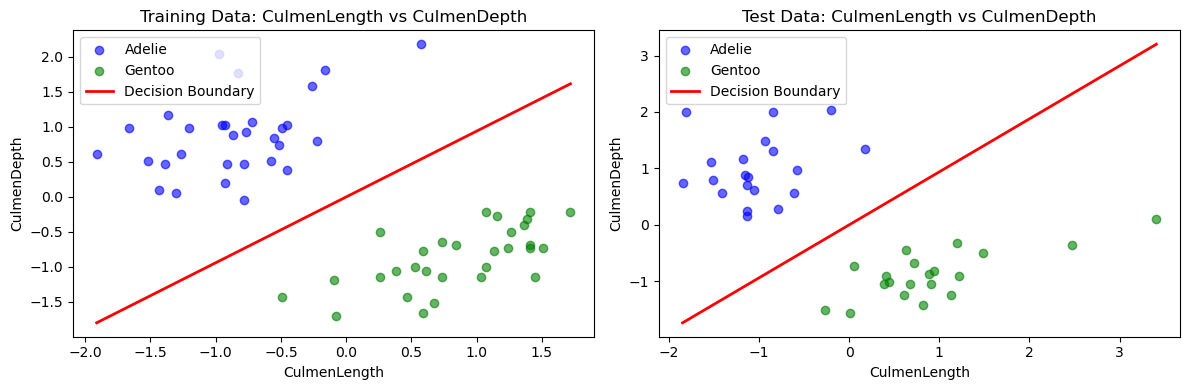

In [26]:
plot_decision_boundary(x_scaled, y, x_test_scaled, y_test, w0, w1, w2, BIAS, FEAT1, FEAT2, CLASS1, CLASS2)